## Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

In [12]:
# Load the dataset and show top 5 rows
df_raw = pd.read_csv(r"C:\Users\Bhawna\Downloads\loan_approval_dataset.csv")
df_raw.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Checking Outliers and null values

In [3]:
print(f'Checking data types:\n{df_raw.dtypes}\n\nChecking null values:\n{df_raw.isna().sum()}')

Checking data types:
loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

Checking null values:
loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


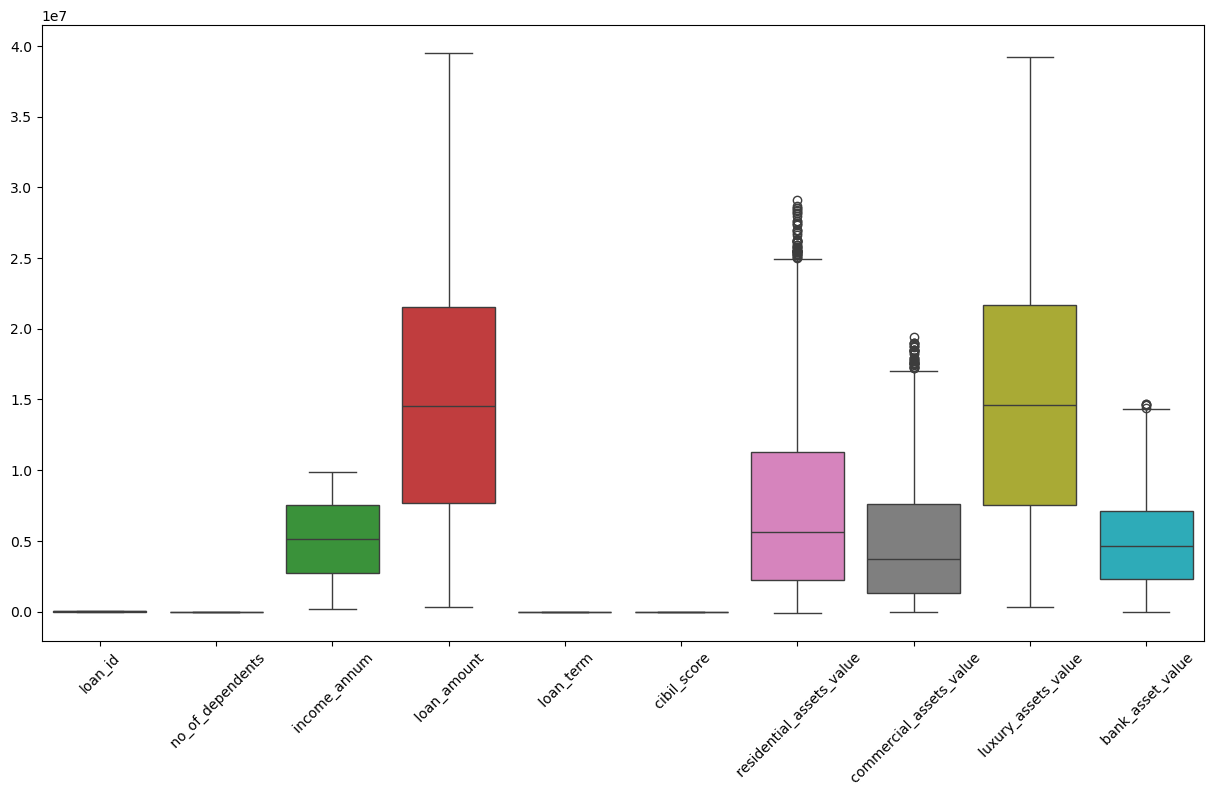

In [4]:
# Checking the outliers in data
plt.figure(figsize=(15,8))
sns.boxplot(df_raw)
plt.xticks(rotation=45)
plt.show()

In [5]:
df_raw.columns = df_raw.columns.str.strip()

In [6]:
# Treating the outliers
columns = ['residential_assets_value','commercial_assets_value','bank_asset_value']
for i in columns:
    q1 = df_raw[i].quantile(0.25)
    q3 = df_raw[i].quantile(0.75)

    # Define inter quartile range
    IQR = q3 - q1

    # Calculate lower bound and the upper bound
    lower_bound = q1 - 1.5*IQR
    upper_bound = q3 + 1.5*IQR

    # Now clip the outliers
    df_raw[i] = np.clip(df_raw[i], lower_bound, upper_bound)


## Scaling numerical features

In [11]:
# Separate numerical columns for scaling
numerical_cols = df_raw.select_dtypes(include=np.number).columns

# Call the library
sc = StandardScaler()

# Store the values after scaling in scaled_values
scaled_values = sc.fit_transform(df_raw[numerical_cols])

# Copy the original dataset and changed its numerical columns values into stored scaled_values
df_scaled = df_raw.copy()
df_scaled[numerical_cols] = scaled_values

## Change categorical columns into numerical columns

In [ ]:
# Separate categorical columns for label encoding
categorical_cols = df_scaled.select_dtypes(exclude=np.number).columns

# Make a copy of df_scaled
df_final = df_scaled.copy()

# Make a loop for picking the categorical columns one by one
for col in categorical_cols:
    le = LabelEncoder()
    df_final[col] = le.fit_transform(df_final[col])


In [18]:
##  Final Dataset Prepared
df_final.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,-1.731645,-0.294102,0,0,1.617979,1.633052,0.192617,1.032792,-0.783495,2.770319,0.832028,0.930707,0
1,-1.730834,-1.473548,1,1,-0.341750,-0.324414,-0.508091,-1.061051,-0.736995,-0.633638,-0.694993,-0.515991,1
2,-1.730022,0.295621,0,0,1.439822,1.610933,1.594031,-0.544840,-0.055003,-0.106426,1.996520,2.408185,1
3,-1.729211,0.295621,0,0,1.119139,1.721525,-0.508091,-0.771045,1.665478,-0.381493,0.897943,0.899926,1
4,-1.728399,1.475067,1,1,1.689242,1.002681,1.594031,-1.264055,0.766488,0.741698,1.568075,0.007282,1
